## 2. Imbalance Analysis and Mitigation

Analisis inicial de desbalance y preparacion de mitigaciones antes de aplicar tecnicas como class_weight, ROS o SMOTE.

### Imports

In [118]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

In [ ]:


DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

# Normaliza target a version agrupada por tier (sin I/II/III ni Division N).
if "max.game.rank" in df_model.columns:
    df_model["max.game.rank"] = (
        df_model["max.game.rank"]
        .astype("string")
        .str.replace(r"\s+Division\s+\d+\s*$", "", regex=True)
        .str.replace(r"\s+(I|II|III)\s*$", "", regex=True)
        .str.strip()
    )
elif "max_rank.name" in df_model.columns:
    df_model["max.game.rank"] = (
        df_model["max_rank.name"]
        .astype("string")
        .str.replace(r"\s+Division\s+\d+\s*$", "", regex=True)
        .str.replace(r"\s+(I|II|III)\s*$", "", regex=True)
        .str.strip()
    )
else:
    raise KeyError("No se encontro max.game.rank ni max_rank.name para construir el target agrupado")

print("Shape del dataset final:", df_model.shape)
display(df_model.head())

Shape del dataset final: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU


In [120]:
print("\nTipos de datos:")
print(df_model.dtypes)

print("\nNulos por columna:")
print(df_model.isna().sum().sort_values(ascending=False).head(20))

print("\nDistribucion del target:")
print(df_model["max.game.rank"].value_counts(dropna=False))


Tipos de datos:
blue.color                                        object
blue.stats.ball.possession_time                  float64
blue.stats.ball.time_in_side                     float64
blue.stats.boost.amount_collected                  int64
blue.stats.boost.amount_collected_big              int64
                                                  ...   
orange.stats.positioning.time_offensive_half     float64
orange.stats.positioning.time_offensive_third    float64
overtime                                            bool
overtime_seconds                                 float64
server.region                                     object
Length: 107, dtype: object

Nulos por columna:
blue.color                                         0
orange.stats.core.goals_against                    0
orange.stats.core.assists                          0
orange.stats.boost.time_zero_boost                 0
orange.stats.boost.time_full_boost                 0
orange.stats.boost.time_boost_75_100        

In [121]:
target_col = "max.game.rank"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (10000, 106)
Shape de y: (10000,)


In [122]:
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Columnas categoricas:", categorical_cols)
print("Numero de categoricas:", len(categorical_cols))

print("\nNumero de numericas/booleanas:", len(numeric_cols))
print("Primeras 20 numericas:", numeric_cols[:20])

Columnas categoricas: ['blue.color', 'orange.color', 'server.region']
Numero de categoricas: 3

Numero de numericas/booleanas: 103
Primeras 20 numericas: ['blue.stats.ball.possession_time', 'blue.stats.ball.time_in_side', 'blue.stats.boost.amount_collected', 'blue.stats.boost.amount_collected_big', 'blue.stats.boost.amount_collected_small', 'blue.stats.boost.amount_overfill', 'blue.stats.boost.amount_overfill_stolen', 'blue.stats.boost.amount_stolen', 'blue.stats.boost.amount_stolen_big', 'blue.stats.boost.amount_stolen_small', 'blue.stats.boost.amount_used_while_supersonic', 'blue.stats.boost.avg_amount', 'blue.stats.boost.bcpm', 'blue.stats.boost.bpm', 'blue.stats.boost.count_collected_big', 'blue.stats.boost.count_collected_small', 'blue.stats.boost.count_stolen_big', 'blue.stats.boost.count_stolen_small', 'blue.stats.boost.time_boost_0_25', 'blue.stats.boost.time_boost_25_50']


In [123]:
class_counts = y.value_counts()
print(class_counts)

print("\nNumero de clases:", y.nunique())
print("Clase mayoritaria:", class_counts.max())
print("Clase minoritaria:", class_counts.min())
print("Imbalance ratio:", class_counts.max() / class_counts.min())

max.game.rank
Champion          4351
Grand Champion    4210
Diamond           1196
Platinum           195
Gold                45
Silver               3
Name: count, dtype: Int64

Numero de clases: 6
Clase mayoritaria: 4351
Clase minoritaria: 3
Imbalance ratio: 1450.3333333333333


In [124]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribucion train:")
print(y_train.value_counts(normalize=True).head())

print("\nDistribucion test:")
print(y_test.value_counts(normalize=True).head())

Train shape: (8000, 106)
Test shape: (2000, 106)

Distribucion train:
max.game.rank
Champion          0.435125
Grand Champion       0.421
Diamond           0.119625
Platinum            0.0195
Gold                0.0045
Name: proportion, dtype: Float64

Distribucion test:
max.game.rank
Champion           0.435
Grand Champion     0.421
Diamond           0.1195
Platinum          0.0195
Gold              0.0045
Name: proportion, dtype: Float64


Distribucion de clases antes de balanceo


,class_label,percentage
0,Champion,43.5125
1,Grand Champion,42.1
2,Diamond,11.9625
3,Platinum,1.95
4,Gold,0.45
5,Silver,0.025


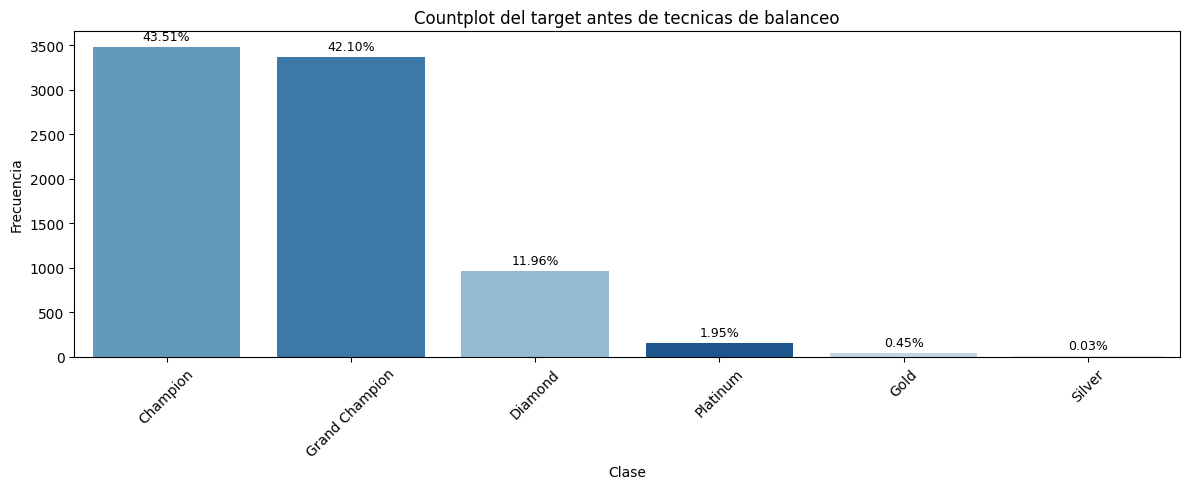

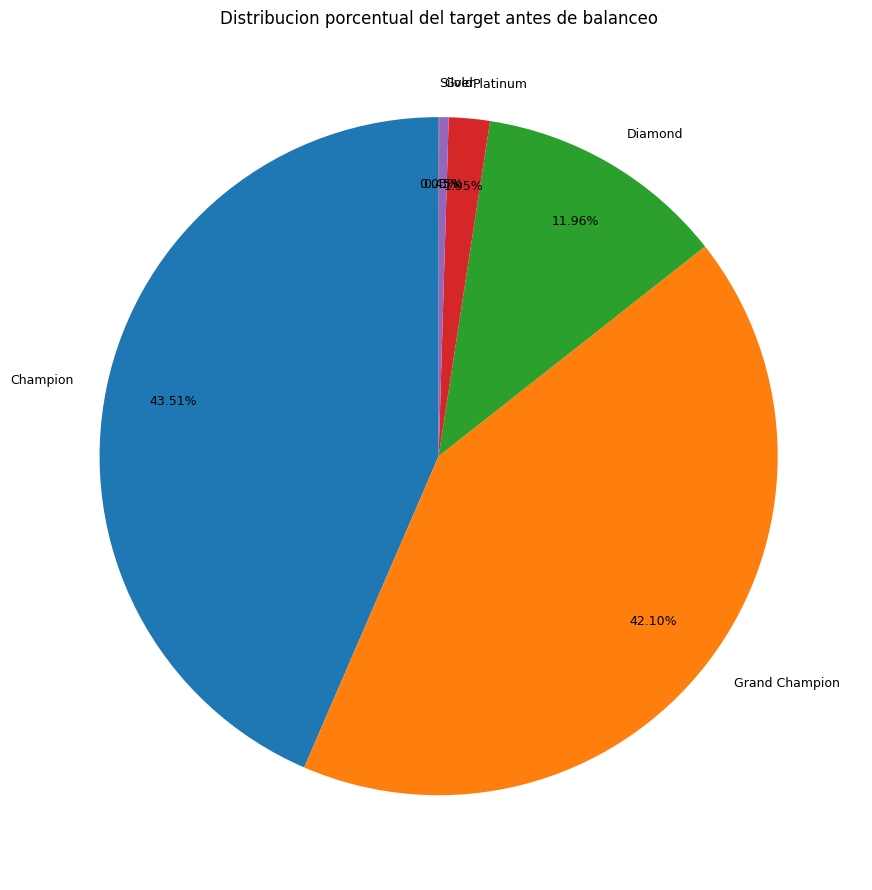

In [125]:


# Visualizacion del desbalance previo a cualquier tecnica de mitigacion.
if "y_train" not in globals():
    raise NameError("No existe 'y_train'. Ejecuta primero la celda de train/test split.")

class_pct = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .rename("percentage")
    .reset_index()
    .rename(columns={"index": "class_label", "max.game.rank": "class_label", "0": "class_label"})
)

if "class_label" not in class_pct.columns:
    class_pct.columns = ["class_label", "percentage"]

print("========================================")
print("Distribucion de clases antes de balanceo")
print("========================================")
display(class_pct)

plt.figure(figsize=(12, 5))
ax = sns.countplot(
    x=y_train,
    hue=y_train,
    order=y_train.value_counts().index,
    palette="Blues_r",
    legend=False,
    dodge=False,
    )
ax.set_title("Countplot del target antes de tecnicas de balanceo")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis="x", rotation=45)
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f"{height / len(y_train) * 100:.2f}%",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 9))
plt.pie(
    class_pct["percentage"],
    labels=class_pct["class_label"],
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 9},
)
plt.title("Distribucion porcentual del target antes de balanceo")
plt.tight_layout()
plt.show()

In [126]:


# =========================
# 1. CARGAR CSV FINAL
# =========================
DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

# Asegura que max.game.rank sea la version agrupada por tier.
if "max.game.rank" in df_model.columns:
    df_model["max.game.rank"] = (
        df_model["max.game.rank"]
        .astype("string")
        .str.replace(r"\s+Division\s+\d+\s*$", "", regex=True)
        .str.replace(r"\s+(I|II|III)\s*$", "", regex=True)
        .str.strip()
    )
elif "max_rank.name" in df_model.columns:
    df_model["max.game.rank"] = (
        df_model["max_rank.name"]
        .astype("string")
        .str.replace(r"\s+Division\s+\d+\s*$", "", regex=True)
        .str.replace(r"\s+(I|II|III)\s*$", "", regex=True)
        .str.strip()
    )
else:
    raise KeyError("No se encontro max.game.rank ni max_rank.name para construir el target agrupado")

print("========================================")
print("Dataset cargado")
print("========================================")
print("Shape original:", df_model.shape)
display(df_model.head())

# =========================
# 2. LIMPIEZA MINIMA PARA MODELADO
# =========================
# Quitamos columnas categoricas que no aportan informacion real
cols_to_drop = ["blue.color", "orange.color"]
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]

if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

print("\n========================================")
print("Columnas eliminadas antes de modelar")
print("========================================")
print(cols_to_drop if cols_to_drop else "No se elimino ninguna columna extra")

# =========================
# 3. DEFINIR TARGET Y FILTRAR CLASES RARAS
# =========================
target_col = "max.game.rank"

if target_col not in df_model.columns:
    raise KeyError(f"No existe la columna target: {target_col}")

print("\n========================================")
print("Distribucion original del target")
print("========================================")
original_counts = df_model[target_col].value_counts().sort_values()
display(original_counts)

# Cambia este valor si quieres ser mas estricto
# Con 5 ya puedes usar StratifiedKFold de 5 folds sin warning
MIN_CLASS_COUNT = 5

valid_classes = original_counts[original_counts >= MIN_CLASS_COUNT].index
removed_classes = original_counts[original_counts < MIN_CLASS_COUNT]

df_model_filtered = df_model[df_model[target_col].isin(valid_classes)].copy()

print("\n========================================")
print("Filtrado de clases raras")
print("========================================")
print(f"Minimo de ejemplos por clase exigido: {MIN_CLASS_COUNT}")
print(f"Numero de clases originales: {df_model[target_col].nunique()}")
print(f"Numero de clases tras filtrado: {df_model_filtered[target_col].nunique()}")
print(f"Filas originales: {len(df_model):,}")
print(f"Filas tras filtrado: {len(df_model_filtered):,}")
print(f"Filas eliminadas: {len(df_model) - len(df_model_filtered):,}")

print("\nClases eliminadas por ser demasiado raras:")
display(removed_classes)

print("\nDistribucion del target tras filtrado:")
filtered_counts = df_model_filtered[target_col].value_counts().sort_values()
display(filtered_counts)

# =========================
# 4. DEFINIR X E y
# =========================
X = df_model_filtered.drop(columns=[target_col])
y = df_model_filtered[target_col]

print("\n========================================")
print("Definicion de X e y")
print("========================================")
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# =========================
# 5. IDENTIFICAR COLUMNAS NUMERICAS Y CATEGORICAS
# =========================
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("\n========================================")
print("Tipos de columnas")
print("========================================")
print("Columnas categoricas:", categorical_cols)
print("Numero de categoricas:", len(categorical_cols))
print("Numero de numericas/booleanas:", len(numeric_cols))

# =========================
# 6. TRAIN / TEST SPLIT ESTRATIFICADO
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("Train / Test split")
print("========================================")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nDistribucion de clases en train:")
display(y_train.value_counts().sort_values())

print("\nDistribucion de clases en test:")
display(y_test.value_counts().sort_values())

# =========================
# 7. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================
# 8. VALIDACION CRUZADA Y METRICAS
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "mcc": make_scorer(matthews_corrcoef)
}

# =========================
# 9. BASELINE DUMMY
# =========================
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

dummy_results = pd.DataFrame(dummy_scores)

print("\n========================================")
print("Dummy baseline results (CV)")
print("========================================")
display(dummy_results)

print("\nMean scores:")
for metric in scoring.keys():
    print(f"{metric}: {dummy_results[f'test_{metric}'].mean():.4f}")

Dataset cargado
Shape original: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU



Columnas eliminadas antes de modelar
['blue.color', 'orange.color']

Distribucion original del target


max.game.rank
Silver               3
Gold                45
Platinum           195
Diamond           1196
Grand Champion    4210
Champion          4351
Name: count, dtype: Int64


Filtrado de clases raras
Minimo de ejemplos por clase exigido: 5
Numero de clases originales: 6
Numero de clases tras filtrado: 5
Filas originales: 10,000
Filas tras filtrado: 9,997
Filas eliminadas: 3

Clases eliminadas por ser demasiado raras:


...


Distribucion de clases en test:


max.game.rank
Gold                9
Platinum           39
Diamond           239
Grand Champion    842
Champion          871
Name: count, dtype: Int64


Dummy baseline results (CV)


,fit_time,score_time,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_mcc
0,0.175209,0.049053,0.435000,0.121254,0.263728,0.087000,0.2,0.0
1,0.188724,0.050564,0.435000,0.121254,0.263728,0.087000,0.2,0.0
2,0.164753,0.030530,0.435272,0.121307,0.264008,0.087054,0.2,0.0
3,0.162785,0.047078,0.435272,0.121307,0.264008,0.087054,0.2,0.0
4,0.201869,0.039047,0.435272,0.121307,0.264008,0.087054,0.2,0.0



Mean scores:
accuracy: 0.4352
f1_macro: 0.1213
f1_weighted: 0.2639
precision_macro: 0.0870
recall_macro: 0.2000
mcc: 0.0000


In [127]:
def build_model_pipeline(model):
    """Create a leakage-safe sklearn Pipeline with shared preprocessor and model."""
    if "preprocessor" not in globals() or not isinstance(preprocessor, ColumnTransformer):
        raise TypeError("'preprocessor' debe existir y ser un ColumnTransformer antes de construir pipelines.")
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])

print("Pipeline anti-leakage verificado: preprocessing dentro de Pipeline con ColumnTransformer.")

Pipeline anti-leakage verificado: preprocessing dentro de Pipeline con ColumnTransformer.


In [128]:
# =========================
# 10. PRIMERA COMPARACION DE MODELOS REALES
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for model_name, model in models.items():
    print("========================================")
    print(f"Entrenando y evaluando: {model_name}")
    print("========================================")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

print("========================================")
print("Resultados - primera comparacion de modelos")
print("========================================")
display(results_df)

Entrenando y evaluando: LogisticRegression
Entrenando y evaluando: DecisionTree
Entrenando y evaluando: RandomForest
Resultados - primera comparacion de modelos


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LogisticRegression,0.765287,0.006604,0.625459,0.018165,0.763741,0.006676,0.655946,0.019027,0.613342,0.030955,0.617254,0.010961
2,RandomForest,0.715893,0.004425,0.420625,0.021410,0.701401,0.004819,0.580035,0.124827,0.400288,0.011818,0.525216,0.008024
1,DecisionTree,0.600477,0.006852,0.409185,0.026257,0.600398,0.007043,0.413194,0.029936,0.406346,0.024042,0.353285,0.011827


In [129]:


# =========================
# ENSSEMBLE MODELS COMPARISON
# =========================
ensemble_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Voting": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        voting="soft"
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=3000, random_state=42),
        cv=3,
        n_jobs=-1
    )
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    print(f"Evaluating: {model_name}")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    ensemble_results.append(row)

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(
    "f1_macro_mean", ascending=False
)

print("========================================")
print("Ensemble models comparison")
print("========================================")
display(ensemble_results_df)

Evaluating: Bagging
Evaluating: AdaBoost
Evaluating: GradientBoosting
Evaluating: Voting
Evaluating: Stacking
Ensemble models comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
4,Stacking,0.768664,0.007806,0.623777,0.033653,0.766315,0.007788,0.690368,0.029359,0.589387,0.036670,0.621915,0.012930
0,Bagging,0.712017,0.007408,0.494399,0.038164,0.703807,0.007832,0.625613,0.071529,0.457603,0.031887,0.522631,0.012695
2,GradientBoosting,0.723647,0.009484,0.486570,0.031436,0.718841,0.010004,0.518514,0.036380,0.468093,0.028243,0.545642,0.015930
3,Voting,0.685259,0.008190,0.485266,0.017784,0.680403,0.008097,0.536780,0.026000,0.460565,0.016046,0.482745,0.013524
1,AdaBoost,0.652870,0.008224,0.443558,0.010069,0.641109,0.009310,0.452571,0.015433,0.445987,0.011346,0.442815,0.011615


## Section 11 - Imbalance Methods (F1-macro oriented)

Comparacion controlada de metodos para desbalance de clases:
- class_weight
- RandomOverSampler (moderado)
- SMOTE (moderado)
- BalancedRandomForest

Todos los modelos se evalúan con el mismo CV y metricas para comparacion justa.

In [130]:

def build_moderate_sampling_strategy(y_train_series: pd.Series) -> dict:
    """Build a moderate target sampling strategy based on the median class frequency."""
    counts = y_train_series.value_counts()
    # Objetivo moderado: llevar clases minoritarias hacia la mediana, no igualar al maximo.
    target = int(counts.median())
    return {cls: target for cls, cnt in counts.items() if cnt < target}

def build_smote_strategy(y_train_series: pd.Series, k_neighbors: int = 3) -> dict:
    """Build a SMOTE strategy only for classes with enough samples for k-neighbors."""
    counts = y_train_series.value_counts()
    target = int(counts.median())
    # SMOTE requiere al menos k_neighbors + 1 muestras por clase.
    return {
        cls: target
        for cls, cnt in counts.items()
        if cnt < target and cnt > k_neighbors
    }

def evaluate_cv_models(model_dict: dict, X_data, y_data, cv_obj, scoring_dict) -> pd.DataFrame:
    """Evaluate multiple models with CV and return mean/std metrics in a DataFrame."""
    rows = []
    for name, model in model_dict.items():
        print(f"Evaluating imbalance candidate: {name}")
        cv_scores = cross_validate(
            model,
            X_data,
            y_data,
            cv=cv_obj,
            scoring=scoring_dict,
            n_jobs=1,
            return_train_score=False
        )
        row = {"model": name}
        for metric in scoring_dict.keys():
            row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()
        rows.append(row)
    return pd.DataFrame(rows)

In [131]:
ros_strategy = build_moderate_sampling_strategy(y_train)
smote_strategy = build_smote_strategy(y_train, k_neighbors=3)

print("========================================")
print("Sampling strategy (moderado)")
print("========================================")
print(f"Clases objetivo para RandomOverSampler: {len(ros_strategy)}")
print(f"Clases objetivo para SMOTE: {len(smote_strategy)}")

imbalance_models = {
    "LR_class_weight_balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42, class_weight="balanced"))
    ]),
    "RF_class_weight_balanced_subsample": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "BalancedRandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", BalancedRandomForestClassifier(
            n_estimators=300,
            random_state=42,
            sampling_strategy="auto",
            replacement=False,
            n_jobs=-1
        ))
    ]),
    "ROS_LR_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ]),
    "ROS_RF_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

if smote_strategy:
    imbalance_models["SMOTE_LR_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ])
    imbalance_models["SMOTE_RF_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
else:
    print("[WARN] No hay clases elegibles para SMOTE con k_neighbors=3 en estrategia moderada.")

imbalance_results_df = evaluate_cv_models(
    imbalance_models,
    X_train,
    y_train,
    cv,
    scoring
).sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

print("\n========================================")
print("Resultados de metodos de desbalance")
print("========================================")
display(imbalance_results_df)

Sampling strategy (moderado)
Clases objetivo para RandomOverSampler: 2
Clases objetivo para SMOTE: 2
Evaluating imbalance candidate: LR_class_weight_balanced
Evaluating imbalance candidate: RF_class_weight_balanced_subsample
Evaluating imbalance candidate: BalancedRandomForest
Evaluating imbalance candidate: ROS_LR_moderate
Evaluating imbalance candidate: ROS_RF_moderate
Evaluating imbalance candidate: SMOTE_LR_moderate
Evaluating imbalance candidate: SMOTE_RF_moderate

Resultados de metodos de desbalance


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LR_class_weight_balanced,0.732401,0.006920,0.600694,0.032464,0.737564,0.006221,0.566895,0.026924,0.668339,0.046991,0.582566,0.010288
3,ROS_LR_moderate,0.750282,0.008313,0.589423,0.017906,0.749728,0.008911,0.579025,0.018338,0.645581,0.037987,0.595716,0.013436
5,SMOTE_LR_moderate,0.752032,0.006634,0.585825,0.024464,0.751368,0.007137,0.573832,0.012716,0.638129,0.046155,0.598053,0.010907
6,SMOTE_RF_moderate,0.717019,0.005833,0.537604,0.032254,0.704721,0.005811,0.688859,0.023010,0.506525,0.030046,0.529966,0.010520
4,ROS_RF_moderate,0.721271,0.006381,0.493859,0.052277,0.709126,0.007460,0.646316,0.090229,0.454066,0.041206,0.535201,0.011221
2,BalancedRandomForest,0.639617,0.010942,0.462834,0.015729,0.646967,0.007522,0.436169,0.012250,0.604613,0.020902,0.454089,0.014472
1,RF_class_weight_balanced_subsample,0.714767,0.003892,0.418468,0.018558,0.698535,0.004017,0.587858,0.119836,0.396732,0.010263,0.523356,0.007573


In [132]:
baseline_blocks = []

if "results_df" in globals():
    baseline_blocks.append(results_df.copy())
if "ensemble_results_df" in globals():
    baseline_blocks.append(ensemble_results_df.copy())
if "dummy_results" in globals() and isinstance(dummy_results, pd.DataFrame):
    baseline_blocks.append(pd.DataFrame([{
        "model": "Dummy_most_frequent",
        "accuracy_mean": dummy_results["test_accuracy"].mean(),
        "accuracy_std": dummy_results["test_accuracy"].std(),
        "f1_macro_mean": dummy_results["test_f1_macro"].mean(),
        "f1_macro_std": dummy_results["test_f1_macro"].std(),
        "f1_weighted_mean": dummy_results["test_f1_weighted"].mean(),
        "f1_weighted_std": dummy_results["test_f1_weighted"].std(),
        "precision_macro_mean": dummy_results["test_precision_macro"].mean(),
        "precision_macro_std": dummy_results["test_precision_macro"].std(),
        "recall_macro_mean": dummy_results["test_recall_macro"].mean(),
        "recall_macro_std": dummy_results["test_recall_macro"].std(),
        "mcc_mean": dummy_results["test_mcc"].mean(),
        "mcc_std": dummy_results["test_mcc"].std(),
    }]))

if baseline_blocks:
    baseline_combined_df = pd.concat(baseline_blocks, ignore_index=True)
    baseline_combined_df["group"] = "baseline"
else:
    baseline_combined_df = pd.DataFrame()

imbalance_tagged_df = imbalance_results_df.copy()
imbalance_tagged_df["group"] = "imbalance"

comparison_df = pd.concat([baseline_combined_df, imbalance_tagged_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

print("========================================")
print("Comparacion global (baseline + imbalance)")
print("========================================")
display(comparison_df[[
    "model", "group",
    "f1_macro_mean", "f1_macro_std",
    "mcc_mean", "mcc_std",
    "recall_macro_mean", "precision_macro_mean", "accuracy_mean"
]].head(20))

Comparacion global (baseline + imbalance)


,model,group,f1_macro_mean,f1_macro_std,mcc_mean,mcc_std,recall_macro_mean,precision_macro_mean,accuracy_mean
0,LogisticRegression,baseline,0.625459,0.018165,0.617254,0.010961,0.613342,0.655946,0.765287
3,Stacking,baseline,0.623777,0.033653,0.621915,0.012930,0.589387,0.690368,0.768664
9,LR_class_weight_balanced,imbalance,0.600694,0.032464,0.582566,0.010288,0.668339,0.566895,0.732401
10,ROS_LR_moderate,imbalance,0.589423,0.017906,0.595716,0.013436,0.645581,0.579025,0.750282
11,SMOTE_LR_moderate,imbalance,0.585825,0.024464,0.598053,0.010907,0.638129,0.573832,0.752032
12,SMOTE_RF_moderate,imbalance,0.537604,0.032254,0.529966,0.010520,0.506525,0.688859,0.717019
4,Bagging,baseline,0.494399,0.038164,0.522631,0.012695,0.457603,0.625613,0.712017
13,ROS_RF_moderate,imbalance,0.493859,0.052277,0.535201,0.011221,0.454066,0.646316,0.721271
5,GradientBoosting,baseline,0.486570,0.031436,0.545642,0.015930,0.468093,0.518514,0.723647
6,Voting,baseline,0.485266,0.017784,0.482745,0.013524,0.460565,0.536780,0.685259


Entrenamiento final en holdout
Mejor candidato por F1-macro CV: LR_class_weight_balanced

Classification report (holdout test):
                precision    recall  f1-score   support

      Champion     0.7629    0.6613    0.7085       871
       Diamond     0.5215    0.6611    0.5830       239
          Gold     0.4375    0.7778    0.5600         9
Grand Champion     0.8204    0.8302    0.8253       842
      Platinum     0.2703    0.5128    0.3540        39

      accuracy                         0.7300      2000
     macro avg     0.5625    0.6886    0.6062      2000
  weighted avg     0.7472    0.7300    0.7351      2000



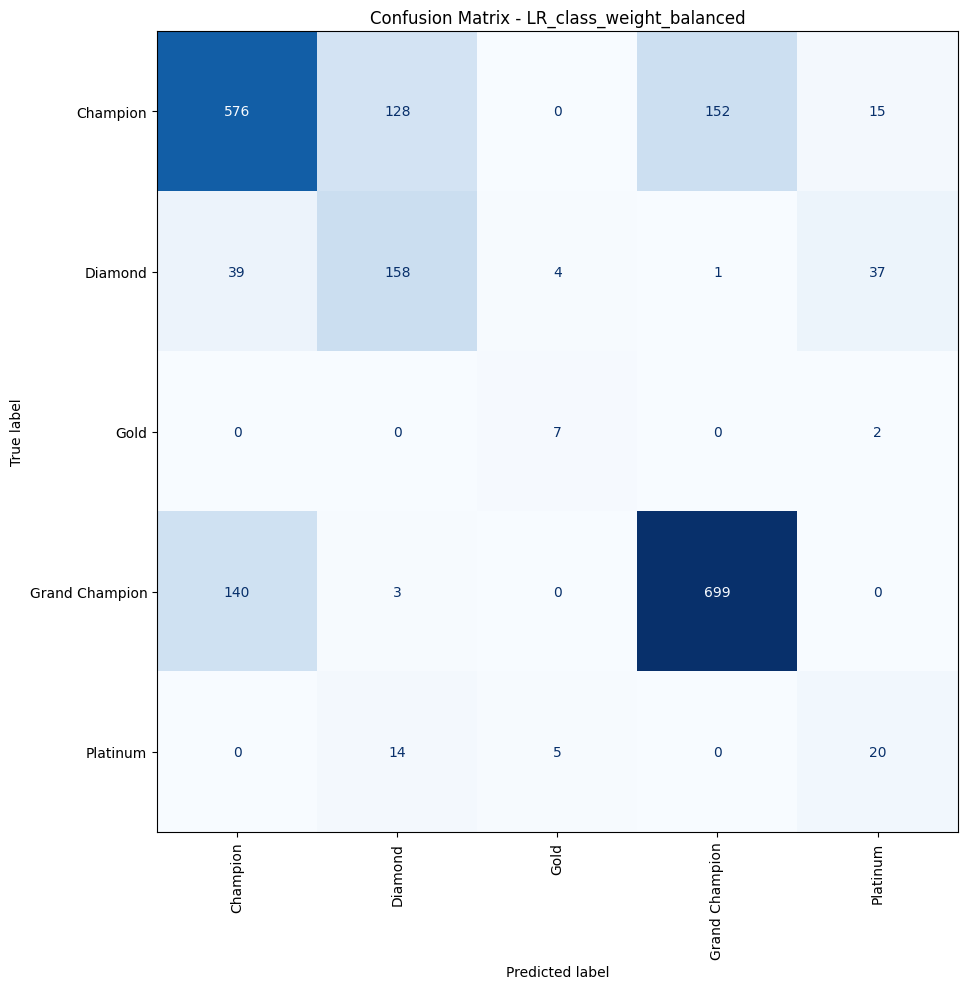

In [133]:
best_model_name = imbalance_results_df.iloc[0]["model"]
best_model = imbalance_models[best_model_name]

print("========================================")
print("Entrenamiento final en holdout")
print("========================================")
print(f"Mejor candidato por F1-macro CV: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nClassification report (holdout test):")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## Section 12 - Advanced Imbalance Improvements

Nuevas mejoras implementadas:
1. Evaluacion ordinal (errores adyacentes vs lejanos).
2. Pipeline SMOTENC-friendly para variables categoricas.
3. RandomizedSearchCV ligero sobre top candidatos.
4. Calibracion de probabilidades + ajuste de umbrales por clase.

In [134]:
def rank_to_ordinal(rank: str) -> int | None:
    """Map tier-only rank labels to ordinal integers (no divisions)."""
    if rank is None or pd.isna(rank):
        return None

    tier_order = {
        "Bronze": 0,
        "Silver": 1,
        "Gold": 2,
        "Platinum": 3,
        "Diamond": 4,
        "Champion": 5,
        "Grand Champion": 6,
        "Supersonic Legend": 7,
    }

    return tier_order.get(str(rank).strip())

def ordinal_distance_report(y_true: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    """Compute ordinal-distance quality metrics between true and predicted tier labels."""
    df_eval = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df_eval["true_ord"] = df_eval["y_true"].apply(rank_to_ordinal)
    df_eval["pred_ord"] = df_eval["y_pred"].apply(rank_to_ordinal)
    df_eval = df_eval.dropna(subset=["true_ord", "pred_ord"]).copy()
    df_eval["ord_dist"] = (df_eval["true_ord"] - df_eval["pred_ord"]).abs()

    total = len(df_eval)
    if total == 0:
        return pd.DataFrame()

    summary = pd.DataFrame({
        "metric": [
            "mean_abs_ordinal_error",
            "pct_exact",
            "pct_within_1",
            "pct_within_2",
        ],
        "value": [
            df_eval["ord_dist"].mean(),
            (df_eval["ord_dist"] == 0).mean(),
            (df_eval["ord_dist"] <= 1).mean(),
            (df_eval["ord_dist"] <= 2).mean(),
        ],
    })
    return summary

In [135]:
# 1) Evaluacion ordinal del mejor modelo actual
ordinal_summary_current = ordinal_distance_report(y_test, y_pred)

print("========================================")
print("Reporte ordinal - modelo actual")
print("========================================")
display(ordinal_summary_current)

# 2) Pipeline alternativo con SMOTENC-friendly (categoricas ordinal-encoded)
numeric_transformer_smotenc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_smotenc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor_smotenc = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_smotenc, numeric_cols),
        ("cat", categorical_transformer_smotenc, categorical_cols),
    ]
)

n_num = len(numeric_cols)
n_cat = len(categorical_cols)
cat_idx = list(range(n_num, n_num + n_cat))

smotenc_strategy = build_smote_strategy(y_train, k_neighbors=3)
if n_cat > 0 and smotenc_strategy:
    smotenc_lr = ImbPipeline(steps=[
        ("preprocessor", preprocessor_smotenc),
        ("sampler", SMOTENC(
            categorical_features=cat_idx,
            sampling_strategy=smotenc_strategy,
            k_neighbors=3,
            random_state=42,
        )),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
    ])

    smotenc_scores = cross_validate(
        smotenc_lr,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    smotenc_row = {"model": "SMOTENC_LR_moderate"}
    for metric in scoring.keys():
        smotenc_row[f"{metric}_mean"] = smotenc_scores[f"test_{metric}"].mean()
        smotenc_row[f"{metric}_std"] = smotenc_scores[f"test_{metric}"].std()

    smotenc_results_df = pd.DataFrame([smotenc_row])
    print("\nSMOTENC candidate ready and evaluated:")
    display(smotenc_results_df)
else:
    smotenc_lr = None
    smotenc_results_df = pd.DataFrame()
    print("\n[WARN] SMOTENC no aplicado: no hay categoricas o no hay estrategia valida.")

Reporte ordinal - modelo actual


,metric,value
0,mean_abs_ordinal_error,0.2815
1,pct_exact,0.7300
2,pct_within_1,0.9885
3,pct_within_2,1.0000



SMOTENC candidate ready and evaluated:


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,SMOTENC_LR_moderate,0.74703,0.008023,0.588331,0.010478,0.746001,0.00842,0.57499,0.006905,0.641227,0.029778,0.589654,0.01313


In [136]:
# 3) Hyperparameter search ligero sobre top 3 candidatos por F1-macro
top3_names = imbalance_results_df.head(3)["model"].tolist()
print("Top 3 para tuning:", top3_names)

search_spaces = {
    "LR_class_weight_balanced": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "ROS_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "SMOTE_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "RF_class_weight_balanced_subsample": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "ROS_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "SMOTE_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "BalancedRandomForest": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
}

tuning_rows = []
best_tuned_estimators = {}

for name in top3_names:
    if name not in imbalance_models:
        continue
    if name not in search_spaces:
        continue

    base_model = imbalance_models[name]
    param_dist = search_spaces[name]

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=min(8, max(1, len(list(param_dist.values())[0]))),
        scoring="f1_macro",
        cv=3,
        random_state=42,
        n_jobs=1,
        verbose=0,
        refit=True,
    )

    print(f"Tuning: {name}")
    search.fit(X_train, y_train)
    best_tuned_estimators[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "best_cv_f1_macro": search.best_score_,
        "best_params": str(search.best_params_),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_cv_f1_macro", ascending=False)
print("\n========================================")
print("Resultados de tuning ligero")
print("========================================")
display(tuning_df)

Top 3 para tuning: ['LR_class_weight_balanced', 'ROS_LR_moderate', 'SMOTE_LR_moderate']
Tuning: LR_class_weight_balanced
Tuning: ROS_LR_moderate
Tuning: SMOTE_LR_moderate

Resultados de tuning ligero


,model,best_cv_f1_macro,best_params
0,LR_class_weight_balanced,0.594888,{'classifier__C': 1.0}
1,ROS_LR_moderate,0.591549,{'classifier__C': 3.0}
2,SMOTE_LR_moderate,0.588074,{'classifier__C': 3.0}


In [137]:
# 4) Calibracion + ajuste de umbrales por clase (sobre mejor tuned disponible)
if not tuning_df.empty:
    chosen_name = tuning_df.iloc[0]["model"]
    chosen_model = best_tuned_estimators[chosen_name]
else:
    chosen_name = imbalance_results_df.iloc[0]["model"]
    chosen_model = imbalance_models[chosen_name]

print("Modelo elegido para calibracion:", chosen_name)

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
 )

# Calibracion robusta para esta version de sklearn (sin modo prefit).
calibrated_model = CalibratedClassifierCV(chosen_model, cv=3, method="sigmoid")
calibrated_model.fit(X_fit, y_fit)

cal_classes = calibrated_model.classes_
cal_proba = calibrated_model.predict_proba(X_cal)

def predict_with_class_multipliers(proba: np.ndarray, classes: np.ndarray, multipliers: dict) -> np.ndarray:
    adj = proba.copy()
    for i, c in enumerate(classes):
        adj[:, i] = adj[:, i] * multipliers.get(c, 1.0)
    idx = adj.argmax(axis=1)
    return classes[idx]

# Busqueda ligera de multiplicadores globales para clases minoritarias
counts_fit = y_fit.value_counts()
median_count = counts_fit.median()
minority_classes = set(counts_fit[counts_fit < median_count].index.tolist())

grid = [0.8, 0.9, 1.0, 1.1, 1.2]
best_f1 = -1.0
best_global_mult = 1.0

for g in grid:
    mult = {c: (g if c in minority_classes else 1.0) for c in cal_classes}
    pred = predict_with_class_multipliers(cal_proba, cal_classes, mult)
    score = f1_score(y_cal, pred, average="macro")
    if score > best_f1:
        best_f1 = score
        best_global_mult = g

best_multipliers = {c: (best_global_mult if c in minority_classes else 1.0) for c in cal_classes}
print(f"Mejor multiplicador global para clases minoritarias: {best_global_mult}")
print(f"F1-macro en calibracion con ajuste: {best_f1:.4f}")

# Evaluacion final en test (sin y con ajuste de umbrales)
test_proba = calibrated_model.predict_proba(X_test)
y_test_pred_cal = calibrated_model.predict(X_test)
y_test_pred_thr = predict_with_class_multipliers(test_proba, cal_classes, best_multipliers)

print("\n=== Holdout - calibrated (default argmax) ===")
print(classification_report(y_test, y_test_pred_cal, digits=4))

print("\n=== Holdout - calibrated + threshold multipliers ===")
print(classification_report(y_test, y_test_pred_thr, digits=4))

print("\n=== Reporte ordinal (threshold multipliers) ===")
display(ordinal_distance_report(y_test, y_test_pred_thr))

Modelo elegido para calibracion: LR_class_weight_balanced
Mejor multiplicador global para clases minoritarias: 1.1
F1-macro en calibracion con ajuste: 0.3400

=== Holdout - calibrated (default argmax) ===
                precision    recall  f1-score   support

      Champion     0.5987    0.7451    0.6639       871
       Diamond     0.0000    0.0000    0.0000       239
          Gold     0.0000    0.0000    0.0000         9
Grand Champion     0.7563    0.8219    0.7877       842
      Platinum     0.0000    0.0000    0.0000        39

      accuracy                         0.6705      2000
     macro avg     0.2710    0.3134    0.2903      2000
  weighted avg     0.5791    0.6705    0.6208      2000


=== Holdout - calibrated + threshold multipliers ===
                precision    recall  f1-score   support

      Champion     0.5993    0.7451    0.6643       871
       Diamond     0.0000    0.0000    0.0000       239
          Gold     0.0000    0.0000    0.0000         9
Grand Cha

,metric,value
0,mean_abs_ordinal_error,0.3570
1,pct_exact,0.6710
2,pct_within_1,0.9765
3,pct_within_2,0.9955


In [138]:
# 5) Experimento ordinal agrupado por tier (sin divisiones).
def rank_to_tier(rank: str) -> str:
    """Normalize rank labels to tier-only categories."""
    if rank is None or pd.isna(rank):
        return "Unknown"

    s = str(rank).strip()
    if not s:
        return "Unknown"

    tier_order = [
        "Supersonic Legend",
        "Grand Champion",
        "Champion",
        "Diamond",
        "Platinum",
        "Gold",
        "Silver",
        "Bronze",
    ]

    for tier in tier_order:
        if s == tier or s.startswith(f"{tier} "):
            return tier

    return s

y_train_tier = y_train.apply(rank_to_tier)
y_test_tier = y_test.apply(rank_to_tier)

tier_ros_strategy = build_moderate_sampling_strategy(y_train_tier)
tier_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=tier_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

tier_cv_scores = cross_validate(
    tier_model,
    X_train,
    y_train_tier,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
    },
    n_jobs=1,
    return_train_score=False,
 )

print("========================================")
print("Tier-level experiment (ordinal grouping)")
print("========================================")
print(f"Tier CV f1_macro mean: {tier_cv_scores['test_f1_macro'].mean():.4f}")
print(f"Tier CV recall_macro mean: {tier_cv_scores['test_recall_macro'].mean():.4f}")

tier_model.fit(X_train, y_train_tier)
y_tier_pred = tier_model.predict(X_test)
print("\nTier holdout report:")
print(classification_report(y_test_tier, y_tier_pred, digits=4))

Tier-level experiment (ordinal grouping)
Tier CV f1_macro mean: 0.5894
Tier CV recall_macro mean: 0.6456

Tier holdout report:
                precision    recall  f1-score   support

      Champion     0.7268    0.7635    0.7447       871
       Diamond     0.6242    0.4100    0.4949       239
          Gold     0.4667    0.7778    0.5833         9
Grand Champion     0.8187    0.8207    0.8197       842
      Platinum     0.2899    0.5128    0.3704        39

      accuracy                         0.7405      2000
     macro avg     0.5852    0.6570    0.6026      2000
  weighted avg     0.7435    0.7405    0.7384      2000



## 4. Results Discussion

Comparacion directa entre baseline y modelos mejorados, con enfoque en interpretacion de metricas y trade-offs para despliegue.

In [139]:

# ---- Construir mejor baseline inicial (sin mejoras de desbalance) ----
baseline_only = baseline_combined_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).copy()
baseline_best_name = baseline_only.iloc[0]["model"]

def get_baseline_model_by_name(name: str):
    if name == "Dummy_most_frequent":
        return dummy_model
    if "model" in results_df.columns and name in set(results_df["model"]):
        clf = models[name]
        return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    if "model" in ensemble_results_df.columns and name in set(ensemble_results_df["model"]):
        clf = ensemble_models[name]
        return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    raise KeyError(f"No se pudo mapear modelo baseline: {name}")

baseline_best_model = get_baseline_model_by_name(baseline_best_name)
baseline_best_model.fit(X_train, y_train)
y_pred_baseline = baseline_best_model.predict(X_test)

# ---- Mejor exact-rank actual (con desbalance) ----
exact_best_name = imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]["model"]
exact_best_model = imbalance_models[exact_best_name]
exact_best_model.fit(X_train, y_train)
y_pred_exact_current = exact_best_model.predict(X_test)

# ---- Tier model actual ----
tier_model.fit(X_train, y_train_tier)
y_pred_tier_current = tier_model.predict(X_test)

comparison_rows = [
    {
        "scenario": "Initial baseline (exact rank)",
        "model": baseline_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(baseline_only.iloc[0]["f1_macro_mean"]),
        "cv_recall_macro": float(baseline_only.iloc[0]["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_baseline),
        "holdout_f1_macro": f1_score(y_test, y_pred_baseline, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_baseline, average="macro"),
    },
    {
        "scenario": "Current improved (exact rank)",
        "model": exact_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]["f1_macro_mean"]),
        "cv_recall_macro": float(imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_exact_current),
        "holdout_f1_macro": f1_score(y_test, y_pred_exact_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_exact_current, average="macro"),
    },
    {
        "scenario": "Current improved (tier rank)",
        "model": "Tier_ROS_LR",
        "task": "tier_rank",
        "cv_f1_macro": float(tier_cv_scores["test_f1_macro"].mean()),
        "cv_recall_macro": float(tier_cv_scores["test_recall_macro"].mean()),
        "holdout_accuracy": accuracy_score(y_test_tier, y_pred_tier_current),
        "holdout_f1_macro": f1_score(y_test_tier, y_pred_tier_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test_tier, y_pred_tier_current, average="macro"),
    },
]

metrics_comparison_df = pd.DataFrame(comparison_rows)

# Delta vs baseline inicial
baseline_ref = metrics_comparison_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_df[f"delta_vs_initial_{col}"] = metrics_comparison_df[col] - baseline_ref[col]

print("========================================")
print("Initial vs Current comparison")
print("========================================")
display(metrics_comparison_df)

Initial vs Current comparison


,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),LogisticRegression,exact_rank,0.625459,0.613342,0.7580,0.660430,0.648889,0.000000,0.000000,0.0000,0.000000,0.000000
1,Current improved (exact rank),LR_class_weight_balanced,exact_rank,0.600694,0.668339,0.7300,0.606152,0.688632,-0.024765,0.054997,-0.0280,-0.054277,0.039744
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.589423,0.645581,0.7405,0.602605,0.656959,-0.036036,0.032239,-0.0175,-0.057824,0.008070


## Section 14 - Production Selector

Seleccion automatica del modelo segun objetivo de negocio:
- `exact_rank`: usar el mejor modelo exacto mejorado.
- `tier_rank`: usar el modelo por tiers (mas robusto).

In [140]:
# Cambia este valor segun tu objetivo final: "exact_rank" o "tier_rank"
DEPLOY_OBJECTIVE = "exact_rank"

if DEPLOY_OBJECTIVE == "exact_rank":
    production_model = exact_best_model
    production_task = "exact_rank"
    production_label_transform = lambda y: y
    production_inverse_transform = lambda y: y
elif DEPLOY_OBJECTIVE == "tier_rank":
    production_model = tier_model
    production_task = "tier_rank"
    production_label_transform = rank_to_tier
    production_inverse_transform = lambda y: y
else:
    raise ValueError("DEPLOY_OBJECTIVE debe ser 'exact_rank' o 'tier_rank'")

print("========================================")
print("Production selector")
print("========================================")
print(f"Objective: {DEPLOY_OBJECTIVE}")
print(f"Task: {production_task}")

if production_task == "exact_rank":
    final_pred = production_model.predict(X_test)
    print("\nProduction holdout report (exact rank):")
    print(classification_report(y_test, final_pred, digits=4))
else:
    final_pred = production_model.predict(X_test)
    print("\nProduction holdout report (tier rank):")
    print(classification_report(y_test_tier, final_pred, digits=4))

def predict_production(X_new: pd.DataFrame) -> pd.Series:
    """Run production inference and return predictions aligned to input index."""
    y_hat = production_model.predict(X_new)
    return pd.Series(y_hat, index=X_new.index, name="prediction")

print("\nFuncion disponible: predict_production(X_new)")

Production selector
Objective: exact_rank
Task: exact_rank

Production holdout report (exact rank):
                precision    recall  f1-score   support

      Champion     0.7629    0.6613    0.7085       871
       Diamond     0.5215    0.6611    0.5830       239
          Gold     0.4375    0.7778    0.5600         9
Grand Champion     0.8204    0.8302    0.8253       842
      Platinum     0.2703    0.5128    0.3540        39

      accuracy                         0.7300      2000
     macro avg     0.5625    0.6886    0.6062      2000
  weighted avg     0.7472    0.7300    0.7351      2000


Funcion disponible: predict_production(X_new)


## Section 15 - Grouped Target (Ignore Divisions)

Target agrupado por rango principal (sin I/II/III):
- Champion
- Diamond
- Gold
- Grand Champion
- Platinum

Objetivo: verificar si al ignorar divisiones mejora estabilidad y calidad global.

In [141]:
# Reusar helper rank_to_tier definido en secciones anteriores
y_group = y.apply(rank_to_tier)

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X,
    y_group,
    test_size=0.2,
    random_state=42,
    stratify=y_group,
 )

group_scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

cv_group = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

group_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

group_ros_strategy = build_moderate_sampling_strategy(y_train_g)
group_ros = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=group_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

group_models = {
    "Grouped_Baseline_LR": group_baseline,
    "Grouped_ROS_LR": group_ros,
}

group_rows = []
for name, model in group_models.items():
    scores = cross_validate(
        model,
        X_train_g,
        y_train_g,
        cv=cv_group,
        scoring=group_scoring,
        n_jobs=1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric in group_scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    group_rows.append(row)

group_results_df = pd.DataFrame(group_rows).sort_values("f1_macro_mean", ascending=False)
display(group_results_df)

best_group_model_name = group_results_df.iloc[0]["model"]
best_group_model = group_models[best_group_model_name]
best_group_model.fit(X_train_g, y_train_g)
y_pred_group = best_group_model.predict(X_test_g)

print("\nBest grouped model:", best_group_model_name)
print("Grouped holdout report:")
print(classification_report(y_test_g, y_pred_group, digits=4))

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
0,Grouped_Baseline_LR,0.764787,0.006226,0.623250,0.020440,0.763234,0.006218,0.654129,0.022651,0.611877,0.032946
1,Grouped_ROS_LR,0.750282,0.008313,0.589423,0.017906,0.749728,0.008911,0.579025,0.018338,0.645581,0.037987



Best grouped model: Grouped_Baseline_LR
Grouped holdout report:
                precision    recall  f1-score   support

      Champion     0.7303    0.7681    0.7487       871
       Diamond     0.6445    0.5690    0.6044       239
          Gold     0.6364    0.7778    0.7000         9
Grand Champion     0.8189    0.8219    0.8204       842
      Platinum     0.7059    0.3077    0.4286        39

      accuracy                         0.7580      2000
     macro avg     0.7072    0.6489    0.6604      2000
  weighted avg     0.7565    0.7580    0.7552      2000



In [142]:
grouped_row = {
    "scenario": "Current improved (grouped, no divisions)",
    "model": best_group_model_name,
    "task": "grouped_rank",
    "cv_f1_macro": float(group_results_df.iloc[0]["f1_macro_mean"]),
    "cv_recall_macro": float(group_results_df.iloc[0]["recall_macro_mean"]),
    "holdout_accuracy": accuracy_score(y_test_g, y_pred_group),
    "holdout_f1_macro": f1_score(y_test_g, y_pred_group, average="macro"),
    "holdout_recall_macro": recall_score(y_test_g, y_pred_group, average="macro"),
}

metrics_comparison_plus_grouped_df = pd.concat(
    [metrics_comparison_df, pd.DataFrame([grouped_row])],
    ignore_index=True,
    sort=False,
)

baseline_ref = metrics_comparison_plus_grouped_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_plus_grouped_df[f"delta_vs_initial_{col}"] = (
        metrics_comparison_plus_grouped_df[col] - baseline_ref[col]
    )

print("========================================")
print("Comparison updated with grouped (no divisions)")
print("========================================")
display(metrics_comparison_plus_grouped_df)

Comparison updated with grouped (no divisions)


,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),LogisticRegression,exact_rank,0.625459,0.613342,0.7580,0.660430,0.648889,0.000000,0.000000,0.0000,0.000000,0.000000
1,Current improved (exact rank),LR_class_weight_balanced,exact_rank,0.600694,0.668339,0.7300,0.606152,0.688632,-0.024765,0.054997,-0.0280,-0.054277,0.039744
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.589423,0.645581,0.7405,0.602605,0.656959,-0.036036,0.032239,-0.0175,-0.057824,0.008070
3,"Current improved (grouped, no divisions)",Grouped_Baseline_LR,grouped_rank,0.623250,0.611877,0.7580,0.660430,0.648889,-0.002209,-0.001465,0.0000,0.000000,0.000000


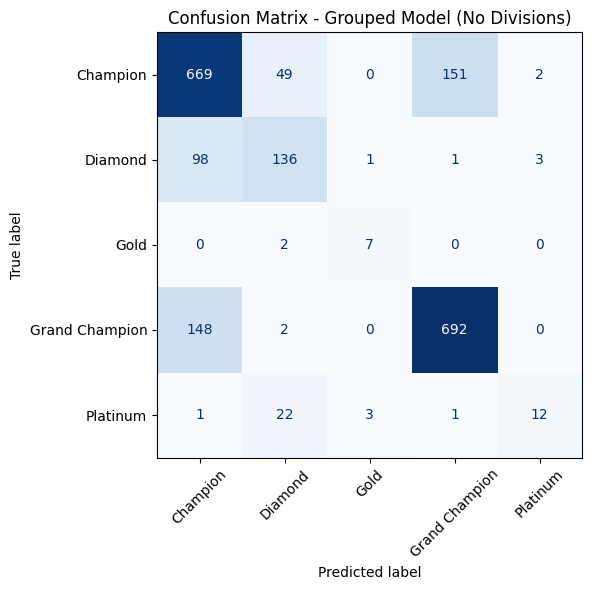

In [143]:
# Confusion matrix - grouped model (sin divisiones)

if "y_test_g" not in globals() or "y_pred_group" not in globals():
    raise NameError("Primero ejecuta la celda de Section 15 para generar y_test_g y y_pred_group.")

group_labels = sorted(pd.Series(y_test_g).unique().tolist())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_g,
    y_pred_group,
    labels=group_labels,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
 )
ax.set_title("Confusion Matrix - Grouped Model (No Divisions)")
plt.tight_layout()
plt.show()

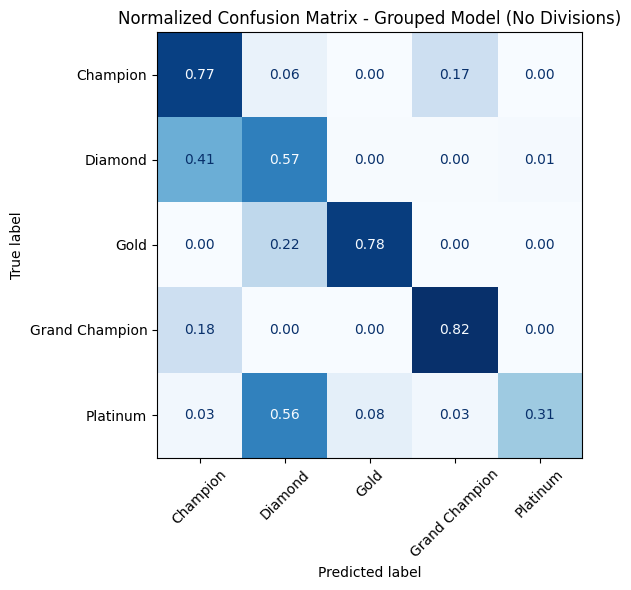

In [144]:
# Confusion matrix normalizada - grouped model (porcentaje por clase real)

if "y_test_g" not in globals() or "y_pred_group" not in globals():
    raise NameError("Primero ejecuta la celda de Section 15 para generar y_test_g y y_pred_group.")

group_labels = sorted(pd.Series(y_test_g).unique().tolist())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_g,
    y_pred_group,
    labels=group_labels,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax,
 )
ax.set_title("Normalized Confusion Matrix - Grouped Model (No Divisions)")
plt.tight_layout()
plt.show()

## 3. Model Comparison and Hyperparameter Tuning

Comparacion estructurada de ensembles y ajuste de hiperparametros con Optuna (MedianPruner) optimizando F1-macro.

In [145]:

warnings.filterwarnings("ignore", category=UserWarning)

required_objects = ["preprocessor", "X_train", "y_train", "cv", "scoring"]
missing_required = [name for name in required_objects if name not in globals()]
if missing_required:
    raise NameError(
        f"Faltan variables para Section 16: {missing_required}. Ejecuta las secciones anteriores primero."
    )

# XGBoost requiere etiquetas codificadas como 0..K-1 para clasificacion multiclase.
label_encoder_section16 = LabelEncoder()
y_train_section16 = pd.Series(
    label_encoder_section16.fit_transform(y_train),
    index=y_train.index,
    name="target_code",
)

n_classes = int(y_train_section16.nunique())
if n_classes < 2:
    raise ValueError("Se requieren al menos 2 clases para entrenar modelos de clasificacion.")

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

ensemble_models_section16 = {
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "AdaBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", AdaBoostClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_base)
    ]),
    "Voting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", VotingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=4000, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("xgb", clone(xgb_base))
            ],
            voting="soft",
            n_jobs=-1
        ))
    ]),
    "Stacking": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", StackingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=4000, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("xgb", clone(xgb_base))
            ],
            final_estimator=LogisticRegression(max_iter=4000, random_state=42),
            cv=3,
            n_jobs=-1
        ))
    ]),
}

ensemble_rows_section16 = []

for model_name, model in ensemble_models_section16.items():
    print(f"Evaluating ensemble model: {model_name}")
    cv_scores = cross_validate(
        model,
        X_train,
        y_train_section16,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()
    ensemble_rows_section16.append(row)

ensemble_results_section16_df = pd.DataFrame(ensemble_rows_section16).sort_values(
    ["f1_macro_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)

print("========================================")
print("Section 16 - Ensemble comparison")
print("========================================")
display(ensemble_results_section16_df)

Evaluating ensemble model: RandomForest
Evaluating ensemble model: AdaBoost
Evaluating ensemble model: XGBoost
Evaluating ensemble model: Voting
Evaluating ensemble model: Stacking
Section 16 - Ensemble comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,Stacking,0.768913,0.007997,0.610521,0.052040,0.766436,0.008301,0.657799,0.057262,0.582591,0.048900,0.622260,0.013441
1,Voting,0.757660,0.009758,0.566343,0.024128,0.751749,0.010499,0.690680,0.043207,0.521894,0.024737,0.600380,0.016821
2,XGBoost,0.738778,0.007992,0.496585,0.041380,0.731468,0.008435,0.610805,0.093689,0.463877,0.028618,0.568384,0.013475
3,AdaBoost,0.640113,0.008302,0.447850,0.026099,0.621553,0.013230,0.466723,0.048338,0.457871,0.023272,0.433162,0.006816
4,RandomForest,0.715393,0.003725,0.412028,0.019808,0.700129,0.003825,0.566469,0.134898,0.394990,0.011194,0.524344,0.006858


In [146]:
required_for_optuna = ["preprocessor", "X_train", "y_train", "cv", "scoring"]
missing_for_optuna = [name for name in required_for_optuna if name not in globals()]
if missing_for_optuna:
    raise NameError(
        f"Faltan variables para el bloque Optuna: {missing_for_optuna}. Ejecuta las secciones anteriores primero."
    )

# Reusa codificacion si existe, o crea una nueva para este bloque.
if "y_train_section16" in globals():
    y_train_optuna = y_train_section16.copy()
else:
    label_encoder_optuna = LabelEncoder()
    y_train_optuna = pd.Series(
        label_encoder_optuna.fit_transform(y_train),
        index=y_train.index,
        name="target_code",
    )

n_classes = int(pd.Series(y_train_optuna).nunique())
cv_optuna = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
optuna_folds = list(cv_optuna.split(X_train, y_train_optuna))

def objective_xgb_pruned(trial: optuna.trial.Trial) -> float:
    params = {
        "objective": "multi:softprob",
        "num_class": n_classes,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "tree_method": "hist",
        "n_jobs": -1,
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
    }

    estimator = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(**params)),
    ])

    best_partial_score = float("-inf")
    for step in range(1, len(optuna_folds) + 1):
        partial_cv = optuna_folds[:step]
        partial_scores = cross_val_score(
            estimator=estimator,
            X=X_train,
            y=y_train_optuna,
            cv=partial_cv,
            scoring="f1_macro",
            n_jobs=1,
        )
        best_partial_score = float(partial_scores.mean())
        trial.report(best_partial_score, step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_partial_score

study_xgb_pruned = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1,
        interval_steps=1
    ),
)

# n_trials moderado para notebook interactivo.
study_xgb_pruned.optimize(objective_xgb_pruned, n_trials=12, show_progress_bar=False)

best_xgb_params = study_xgb_pruned.best_params.copy()
best_xgb_params.update({
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "random_state": 42,
    "tree_method": "hist",
    "n_jobs": -1,
})

best_xgb_optuna_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(**best_xgb_params)),
])

best_xgb_optuna_scores = cross_validate(
    best_xgb_optuna_model,
    X_train,
    y_train_optuna,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

xgb_optuna_row = {"model": "XGBoost_OptunaPruned"}
for metric in scoring.keys():
    xgb_optuna_row[f"{metric}_mean"] = best_xgb_optuna_scores[f"test_{metric}"].mean()
    xgb_optuna_row[f"{metric}_std"] = best_xgb_optuna_scores[f"test_{metric}"].std()

xgb_optuna_results_df = pd.DataFrame([xgb_optuna_row])

print("========================================")
print("Section 16 - Optuna with MedianPruner (XGBoost)")
print("========================================")
print("Best F1-macro:", study_xgb_pruned.best_value)
print("Best params:", study_xgb_pruned.best_params)
display(study_xgb_pruned.trials_dataframe().sort_values("value", ascending=False).head(10))
display(xgb_optuna_results_df)

[I 2026-03-21 22:33:48,286] A new study created in memory with name: no-name-b655215d-dba1-44d7-9395-e426374f446f
[I 2026-03-21 22:33:57,733] Trial 0 finished with value: 0.48921351039671385 and parameters: {'n_estimators': 281, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 7.585243326167403, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_lambda': 0.0017073967431528124, 'gamma': 2.5985284373248057}. Best is trial 0 with value: 0.48921351039671385.
[I 2026-03-21 22:34:11,962] Trial 1 finished with value: 0.503081910687239 and parameters: {'n_estimators': 360, 'learning_rate': 0.11114989443094977, 'max_depth': 3, 'min_child_weight': 11.669008373781937, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_lambda': 0.005337032762603957, 'gamma': 0.5502135295603015}. Best is trial 1 with value: 0.503081910687239.
[I 2026-03-21 22:34:29,533] Trial 2 finished with value: 0.48837627319032384 and parameters: {'n_e

Section 16 - Optuna with MedianPruner (XGBoost)
Best F1-macro: 0.5168273145319483
Best params: {'n_estimators': 172, 'learning_rate': 0.2521267904777921, 'max_depth': 10, 'min_child_weight': 9.892370829281072, 'subsample': 0.7218455076693483, 'colsample_bytree': 0.6390688456025535, 'reg_lambda': 0.5456725485601477, 'gamma': 1.320457481218804}


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_lambda,params_subsample,state
4,4,0.516827,2026-03-21 22:34:43.631328,2026-03-21 22:34:52.372803,0 days 00:00:08.741475,0.639069,1.320457,0.252127,10,9.892371,172,0.545673,0.721846,COMPLETE
3,3,0.505264,2026-03-21 22:34:29.534004,2026-03-21 22:34:43.630328,0 days 00:00:14.096324,0.618580,0.511572,0.144477,4,6.656579,310,0.269265,0.836966,COMPLETE
1,1,0.503082,2026-03-21 22:33:57.734267,2026-03-21 22:34:11.962354,0 days 00:00:14.228087,0.684936,0.550214,0.111150,3,11.669008,360,0.005337,0.932977,COMPLETE
0,0,0.489214,2026-03-21 22:33:48.288971,2026-03-21 22:33:57.733266,0 days 00:00:09.444295,0.662398,2.598528,0.253700,8,7.585243,281,0.001707,0.662407,COMPLETE
2,2,0.488376,2026-03-21 22:34:11.963358,2026-03-21 22:34:29.533004,0 days 00:00:17.569646,0.655798,1.099086,0.059584,6,4.203521,256,0.014743,0.844741,COMPLETE
8,8,0.469933,2026-03-21 22:35:01.104400,2026-03-21 22:35:08.292997,0 days 00:00:07.188597,0.994755,0.596147,0.063333,4,9.824167,248,1.227380,0.629820,PRUNED
11,11,0.467772,2026-03-21 22:35:21.198223,2026-03-21 22:35:27.284693,0 days 00:00:06.086470,0.773743,1.584228,0.297346,5,6.722933,411,0.277316,0.827968,PRUNED
5,5,0.443099,2026-03-21 22:34:52.373803,2026-03-21 22:34:53.849467,0 days 00:00:01.475664,0.865009,1.560204,0.053881,3,11.002524,192,0.017654,0.703512,PRUNED
9,9,0.436773,2026-03-21 22:35:08.293997,2026-03-21 22:35:10.353344,0 days 00:00:02.059347,0.629618,0.347607,0.160153,8,9.019079,151,0.027156,0.908508,PRUNED
10,10,0.431088,2026-03-21 22:35:10.354345,2026-03-21 22:35:21.197223,0 days 00:00:10.842878,0.782531,2.029717,0.010206,10,1.197581,481,6.903717,0.758884,PRUNED


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,XGBoost_OptunaPruned,0.735652,0.009068,0.525016,0.06048,0.730524,0.010288,0.614349,0.101624,0.493066,0.049084,0.565097,0.015615


In [147]:
def _standardize_results_for_comparison(df_in: pd.DataFrame, source_name: str) -> pd.DataFrame:
    if df_in is None or df_in.empty:
        return pd.DataFrame()

    df = df_in.copy()

    if "model" not in df.columns and "experiment" in df.columns:
        df["model"] = df["experiment"]
    if "model" not in df.columns:
        df["model"] = source_name

    required_cols = [
        "accuracy_mean",
        "recall_macro_mean",
        "precision_macro_mean",
        "f1_macro_mean",
        "mcc_mean",
    ]
    for col in required_cols:
        if col not in df.columns:
            df[col] = np.nan

    out = df[[
        "model",
        "accuracy_mean",
        "recall_macro_mean",
        "precision_macro_mean",
        "f1_macro_mean",
        "mcc_mean",
    ]].copy()
    out["source"] = source_name
    return out

comparison_blocks = []

if "results_df" in globals():
    comparison_blocks.append(_standardize_results_for_comparison(results_df, "base_models"))
if "ensemble_results_df" in globals():
    comparison_blocks.append(_standardize_results_for_comparison(ensemble_results_df, "legacy_ensembles"))
if "imbalance_results_df" in globals():
    comparison_blocks.append(_standardize_results_for_comparison(imbalance_results_df, "imbalance"))
if "ensemble_results_section16_df" in globals():
    comparison_blocks.append(_standardize_results_for_comparison(ensemble_results_section16_df, "section16_ensembles"))
if "xgb_optuna_results_df" in globals():
    comparison_blocks.append(_standardize_results_for_comparison(xgb_optuna_results_df, "optuna_pruned"))

if not comparison_blocks:
    raise ValueError("No hay resultados disponibles para consolidar.")

metrics_consolidated_df = (
    pd.concat(comparison_blocks, ignore_index=True)
    .dropna(subset=["f1_macro_mean"])
    .sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)
    .reset_index(drop=True)
)

metrics_consolidated_df = metrics_consolidated_df.rename(columns={
    "accuracy_mean": "Accuracy",
    "recall_macro_mean": "Recall",
    "precision_macro_mean": "Precision",
    "f1_macro_mean": "F1-macro",
    "mcc_mean": "MCC",
})

print("========================================")
print("Section 16 - Tabla consolidada de metricas")
print("========================================")
display(metrics_consolidated_df[[
    "model",
    "source",
    "Accuracy",
    "Recall",
    "Precision",
    "F1-macro",
    "MCC",
]])

Section 16 - Tabla consolidada de metricas


,model,source,Accuracy,Recall,Precision,F1-macro,MCC
0,LogisticRegression,base_models,0.765287,0.613342,0.655946,0.625459,0.617254
1,Stacking,legacy_ensembles,0.768664,0.589387,0.690368,0.623777,0.621915
2,Stacking,section16_ensembles,0.768913,0.582591,0.657799,0.610521,0.622260
3,LR_class_weight_balanced,imbalance,0.732401,0.668339,0.566895,0.600694,0.582566
4,ROS_LR_moderate,imbalance,0.750282,0.645581,0.579025,0.589423,0.595716
5,SMOTE_LR_moderate,imbalance,0.752032,0.638129,0.573832,0.585825,0.598053
6,Voting,section16_ensembles,0.757660,0.521894,0.690680,0.566343,0.600380
7,SMOTE_RF_moderate,imbalance,0.717019,0.506525,0.688859,0.537604,0.529966
8,XGBoost_OptunaPruned,optuna_pruned,0.735652,0.493066,0.614349,0.525016,0.565097
9,XGBoost,section16_ensembles,0.738778,0.463877,0.610805,0.496585,0.568384


In [148]:
# Docstrings breves para funciones clave del notebook de modelos.
model_docstrings = {
    "build_model_pipeline": "Create a leakage-safe model pipeline with shared preprocessor.",
    "build_moderate_sampling_strategy": "Build moderate class targets using median class frequency.",
    "build_smote_strategy": "Build SMOTE strategy for eligible minority classes.",
    "evaluate_cv_models": "Run CV for multiple models and aggregate mean/std metrics.",
    "rank_to_ordinal": "Map rank labels into an ordinal scale.",
    "ordinal_distance_report": "Summarize ordinal distance quality metrics.",
    "predict_with_class_multipliers": "Apply per-class multipliers to probabilities before argmax.",
    "rank_to_tier": "Collapse rank labels to tier-only categories.",
    "predict_production": "Generate production predictions preserving index alignment.",
    "plot_confusion_matrix_normalized": "Plot normalized confusion matrix for visual comparison.",
}

for func_name, doc in model_docstrings.items():
    if func_name in globals() and callable(globals()[func_name]):
        globals()[func_name].__doc__ = doc

print(f"Docstrings aplicados a funciones de modelos: {sum(name in globals() for name in model_docstrings)}")

Docstrings aplicados a funciones de modelos: 10


Comparacion Base vs Balanceado (RandomForest)


,Modelo,Técnica de Balanceo,Accuracy,F1-macro,MCC
0,RandomForest,Base,0.715393,0.412028,0.524344
1,RandomForest,class_weight,0.716019,0.426418,0.525559


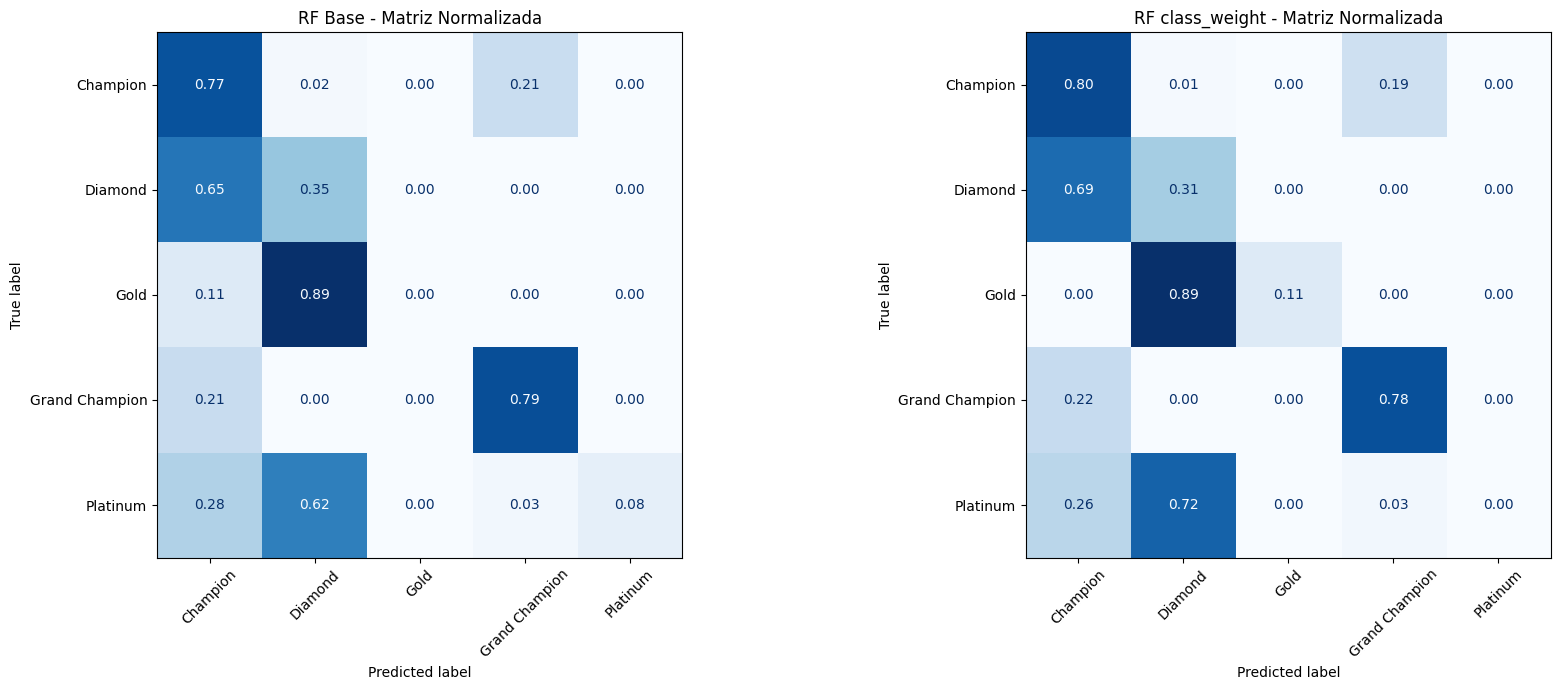

In [149]:
required_for_rf_compare = ["preprocessor", "X_train", "X_test", "y_train", "y_test"]
missing_for_rf_compare = [name for name in required_for_rf_compare if name not in globals()]
if missing_for_rf_compare:
    raise NameError(
        f"Faltan variables para comparacion RF base vs balanceado: {missing_for_rf_compare}. Ejecuta secciones anteriores primero."
    )

def plot_confusion_matrix_normalized(y_true, y_pred, title, labels=None, ax=None, cmap="Blues"):
    """Plot a normalized confusion matrix for quick side-by-side model comparison."""
    if labels is None:
        labels = sorted(pd.Series(y_true).astype(str).unique().tolist())

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        labels=labels,
        normalize="true",
        cmap=cmap,
        xticks_rotation=45,
        values_format=".2f",
        colorbar=False,
        ax=ax,
    )
    disp.ax_.set_title(title)
    return disp

rf_scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "mcc": make_scorer(matthews_corrcoef),
}

rf_base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_balanced_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_base_scores = cross_validate(
    estimator=rf_base_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=rf_scoring,
    n_jobs=1,
    return_train_score=False,
    error_score="raise",
)

rf_balanced_scores = cross_validate(
    estimator=rf_balanced_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=rf_scoring,
    n_jobs=1,
    return_train_score=False,
    error_score="raise",
)

rf_base_vs_balanced_df = pd.DataFrame([
    {
        "Modelo": "RandomForest",
        "Técnica de Balanceo": "Base",
        "Accuracy": float(rf_base_scores["test_accuracy"].mean()),
        "F1-macro": float(rf_base_scores["test_f1_macro"].mean()),
        "MCC": float(rf_base_scores["test_mcc"].mean()),
    },
    {
        "Modelo": "RandomForest",
        "Técnica de Balanceo": "class_weight",
        "Accuracy": float(rf_balanced_scores["test_accuracy"].mean()),
        "F1-macro": float(rf_balanced_scores["test_f1_macro"].mean()),
        "MCC": float(rf_balanced_scores["test_mcc"].mean()),
    },
])

print("========================================")
print("Comparacion Base vs Balanceado (RandomForest)")
print("========================================")
display(rf_base_vs_balanced_df)

rf_base_pipeline.fit(X_train, y_train)
rf_balanced_pipeline.fit(X_train, y_train)

rf_base_pred = rf_base_pipeline.predict(X_test)
rf_balanced_pred = rf_balanced_pipeline.predict(X_test)

labels_cm = sorted(pd.Series(y_test).astype(str).unique().tolist())
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_confusion_matrix_normalized(
    y_true=y_test,
    y_pred=rf_base_pred,
    title="RF Base - Matriz Normalizada",
    labels=labels_cm,
    ax=axes[0],
)

plot_confusion_matrix_normalized(
    y_true=y_test,
    y_pred=rf_balanced_pred,
    title="RF class_weight - Matriz Normalizada",
    labels=labels_cm,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

In [150]:
# Exportacion de Resultados

if "metrics_consolidated_df" not in globals() or metrics_consolidated_df.empty:
    raise NameError(
        "No existe 'metrics_consolidated_df' o esta vacio. Ejecuta primero la consolidacion de metricas."
    )

export_dir = "datasets"
os.makedirs(export_dir, exist_ok=True)
export_path = os.path.join(export_dir, "metrics_consolidated_final.csv")

metrics_consolidated_df.to_csv(export_path, index=False, encoding="utf-8")
print("========================================")
print("Exportacion de Resultados")
print("========================================")
print(f"Archivo generado: {export_path}")
display(metrics_consolidated_df.head(10))

Exportacion de Resultados
Archivo generado: datasets\metrics_consolidated_final.csv


,model,Accuracy,Recall,Precision,F1-macro,MCC,source
0,LogisticRegression,0.765287,0.613342,0.655946,0.625459,0.617254,base_models
1,Stacking,0.768664,0.589387,0.690368,0.623777,0.621915,legacy_ensembles
2,Stacking,0.768913,0.582591,0.657799,0.610521,0.622260,section16_ensembles
3,LR_class_weight_balanced,0.732401,0.668339,0.566895,0.600694,0.582566,imbalance
4,ROS_LR_moderate,0.750282,0.645581,0.579025,0.589423,0.595716,imbalance
5,SMOTE_LR_moderate,0.752032,0.638129,0.573832,0.585825,0.598053,imbalance
6,Voting,0.757660,0.521894,0.690680,0.566343,0.600380,section16_ensembles
7,SMOTE_RF_moderate,0.717019,0.506525,0.688859,0.537604,0.529966,imbalance
8,XGBoost_OptunaPruned,0.735652,0.493066,0.614349,0.525016,0.565097,optuna_pruned
9,XGBoost,0.738778,0.463877,0.610805,0.496585,0.568384,section16_ensembles


Modelos usados para las matrices


,model,source,Accuracy,Recall,Precision,F1-macro,MCC
0,LogisticRegression,base_models,0.765287,0.613342,0.655946,0.625459,0.617254
1,Stacking,legacy_ensembles,0.768664,0.589387,0.690368,0.623777,0.621915
2,Stacking,section16_ensembles,0.768913,0.582591,0.657799,0.610521,0.622260
3,LR_class_weight_balanced,imbalance,0.732401,0.668339,0.566895,0.600694,0.582566
4,ROS_LR_moderate,imbalance,0.750282,0.645581,0.579025,0.589423,0.595716
5,SMOTE_LR_moderate,imbalance,0.752032,0.638129,0.573832,0.585825,0.598053
6,Voting,section16_ensembles,0.757660,0.521894,0.690680,0.566343,0.600380
7,SMOTE_RF_moderate,imbalance,0.717019,0.506525,0.688859,0.537604,0.529966


Training: LogisticRegression
[base_models]
Training: Stacking
[legacy_ensembles]
Training: Stacking
[section16_ensembles]
Training: LR_class_weight_balanced
[imbalance]
Training: ROS_LR_moderate
[imbalance]
Training: SMOTE_LR_moderate
[imbalance]
Training: Voting
[section16_ensembles]
Training: SMOTE_RF_moderate
[imbalance]


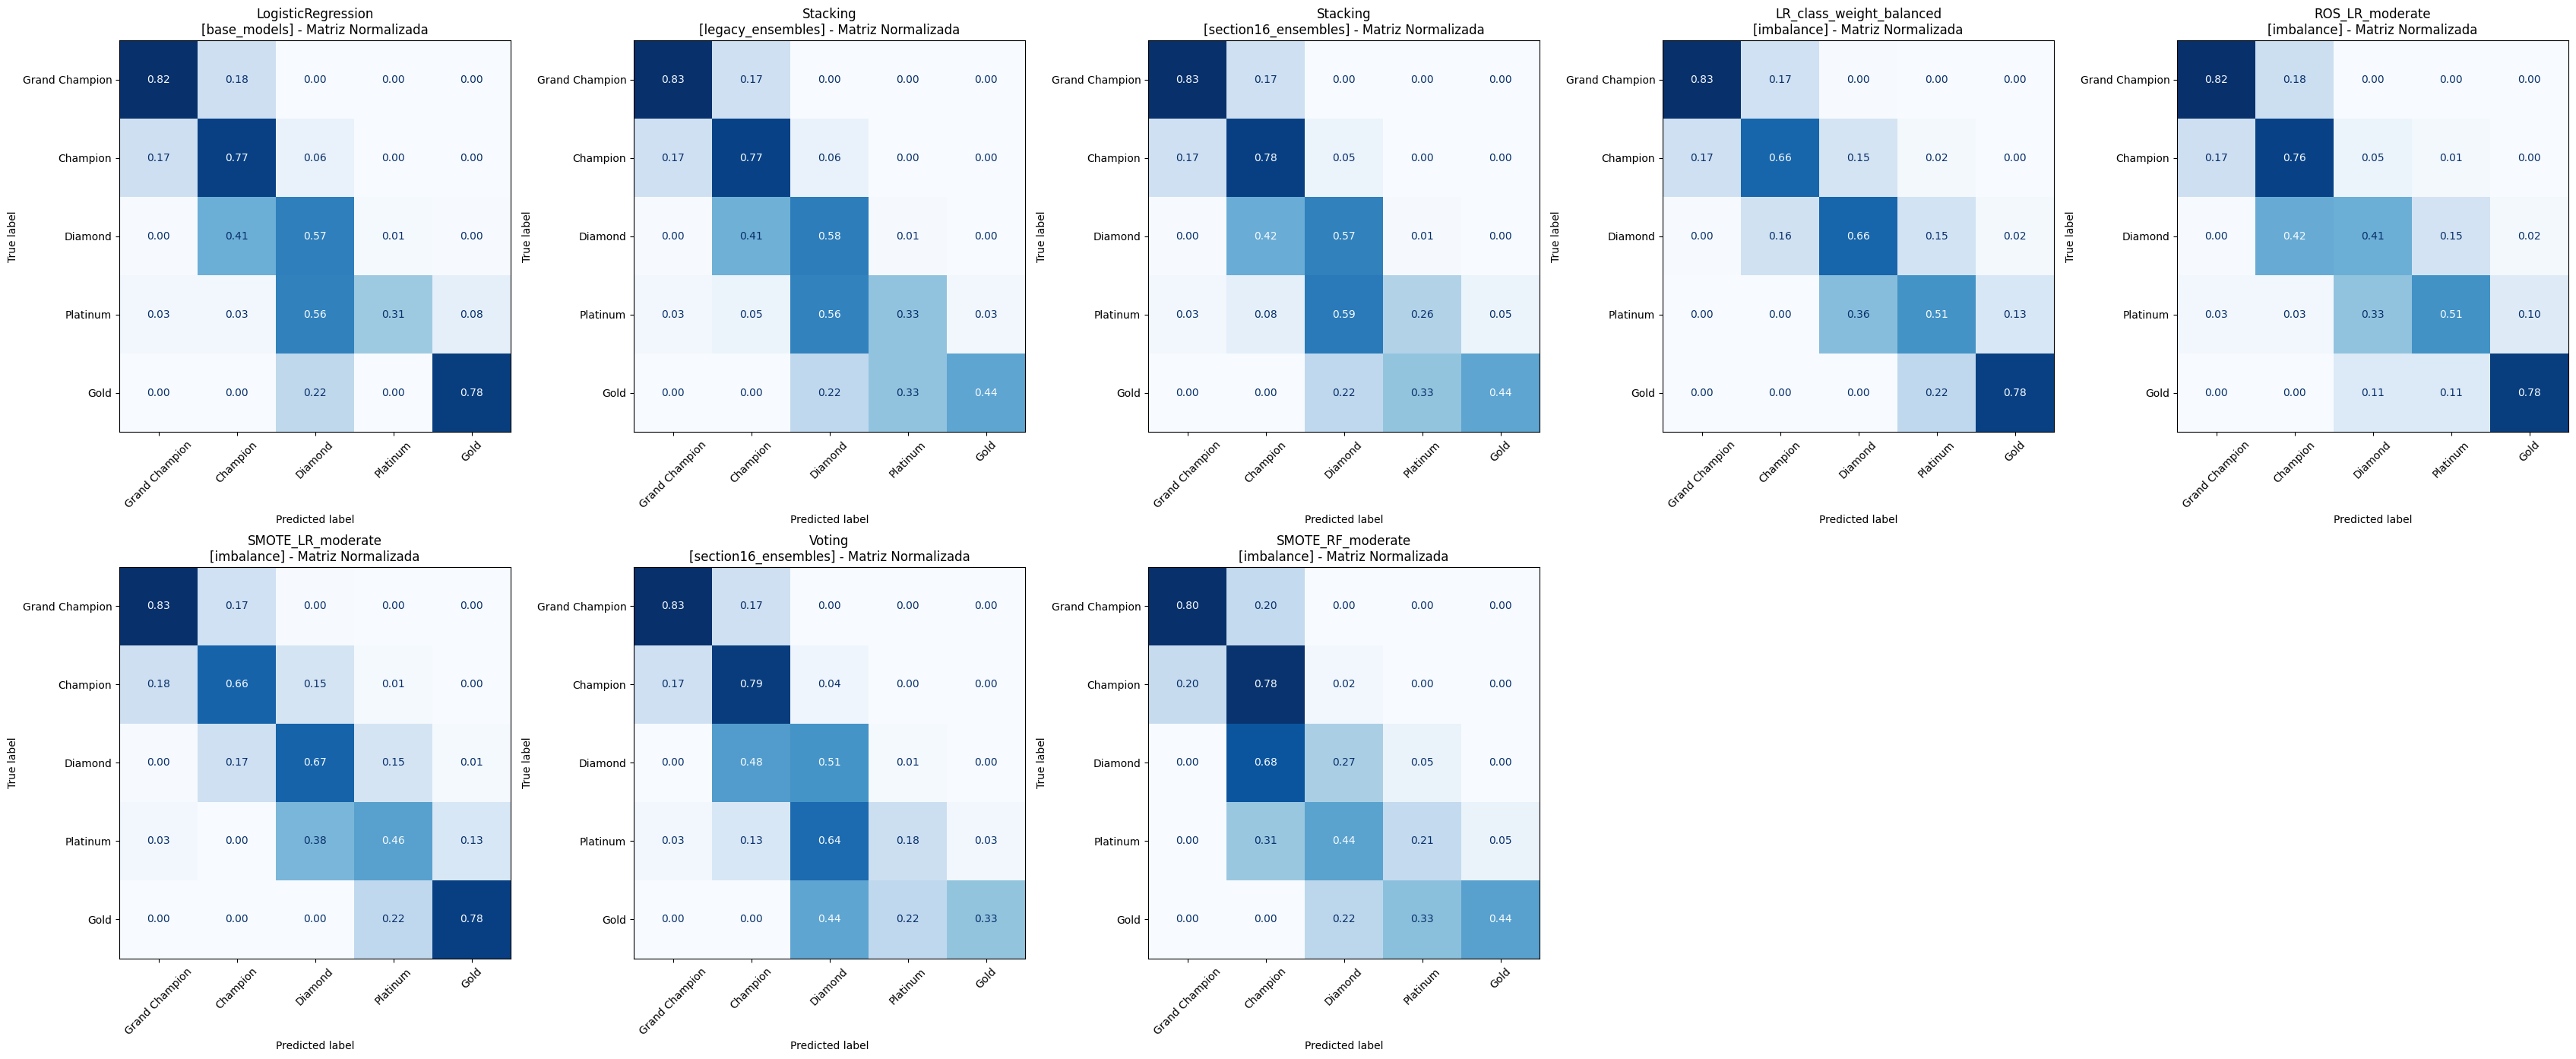

In [151]:

labels_cm = [
    "Grand Champion",
    "Champion",
    "Diamond",
    "Platinum",
    "Gold",
]

def plot_confusion_matrix_normalized(y_true, y_pred, title, labels=None, ax=None, cmap="Blues"):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        labels=labels,
        normalize="true",
        cmap=cmap,
        xticks_rotation=45,
        values_format=".2f",
        colorbar=False,
        ax=ax,
    )
    disp.ax_.set_title(title)
    return disp

top10_df = (
    metrics_consolidated_df
    .sort_values(["F1-macro", "MCC"], ascending=False)
    .head(10)
    .copy()
)

# Excluir modelos XGBoost porque necesitan y codificada como enteros
top10_df = top10_df[
    ~top10_df["model"].isin(["XGBoost", "XGBoost_OptunaPruned"])
].copy()

print("========================================")
print("Modelos usados para las matrices")
print("========================================")
display(top10_df[["model", "source", "Accuracy", "Recall", "Precision", "F1-macro", "MCC"]])

def get_model_object(model_name, source_name):
    if model_name == "LogisticRegression" and source_name == "base_models":
        return lr_baseline

    if model_name == "DecisionTree" and source_name == "base_models":
        return models["DecisionTree"]

    if model_name == "RandomForest" and source_name == "base_models":
        return models["RandomForest"]

    if source_name == "legacy_ensembles":
        if model_name == "Stacking":
            return stacking_model
        return ensemble_models[model_name]

    if source_name == "section16_ensembles":
        if model_name == "XGBoost":
            return None
        return ensemble_models_section16[model_name]

    if source_name == "imbalance":
        if model_name == "SMOTE_LR_moderate":
            return smote_lr
        return imbalance_models[model_name]

    if model_name == "XGBoost_OptunaPruned" and source_name == "optuna_pruned":
        return None

    return None

def ensure_pipeline(model_obj):
    cls_name = model_obj.__class__.__name__.lower()
    module_name = model_obj.__class__.__module__.lower()

    if "pipeline" in cls_name or "pipeline" in module_name:
        return clone(model_obj)

    return build_model_pipeline(clone(model_obj))

predictions = {}
missing_models = []

for _, row in top10_df.iterrows():
    model_name = row["model"]
    source_name = row["source"]

    model_obj = get_model_object(model_name, source_name)

    if model_obj is None:
        missing_models.append((model_name, source_name))
        continue

    fitted_model = ensure_pipeline(model_obj)

    display_name = f"{model_name}\n[{source_name}]"
    print(f"Training: {display_name}")

    fitted_model.fit(X_train, y_train)
    predictions[display_name] = fitted_model.predict(X_test)

if missing_models:
    print("\nNo se pudieron resolver estos modelos:")
    for item in missing_models:
        print(item)

fig, axes = plt.subplots(2, 5, figsize=(34, 14))
axes = axes.ravel()

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    plot_confusion_matrix_normalized(
        y_true=y_test,
        y_pred=y_pred,
        title=f"{model_name} - Matriz Normalizada",
        labels=labels_cm,
        ax=ax,
    )

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()